# Coverage breadth

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [2]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


## Mosdepth coverage

In [3]:
depth = []

basepath = Path("../analysis/downsample_40M/downstream/mosdepth")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.mosdepth.global.dist.txt"
    d = pd.read_csv(tsv, sep="\t", names=["region", "depth", "cumulative"])
    #d = d.query("region == 'total'")
    d["relative_depth"] = d.groupby("region")["cumulative"].transform(
        lambda x: x.rolling(2).apply(lambda x: x.iloc[1]-x.iloc[0]).fillna(0))
    d["cumulative_percentage"] = d["cumulative"] * 100
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    depth.append(d)

depth = pd.concat(depth).reset_index(drop=True)
depth.head()

,region,depth,cumulative,relative_depth,cumulative_percentage,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,chr1,74,0.00008,0.00000,0.008,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,chr1,73,0.00009,0.00001,0.009,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
2,chr1,72,0.00010,0.00001,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
3,chr1,71,0.00010,0.00000,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
4,chr1,70,0.00011,0.00001,0.011,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell


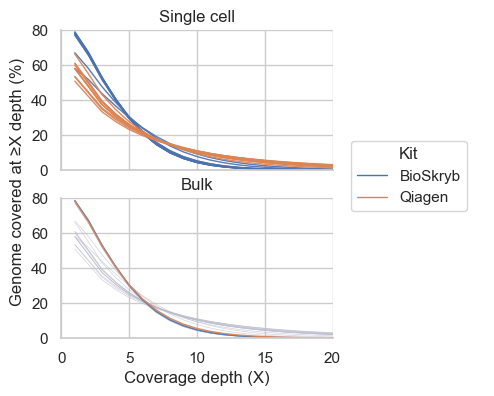

In [4]:
d = depth.query("depth > 0 & region == 'total'").copy()

fig = plt.figure(figsize=(3.5,4))
fig.text(0, 0.5, "Genome covered at ≥X depth (%)", ha="center", va="center", 
         rotation=90, fontsize=12)

p = (
    so.Plot(d, x="depth", y="cumulative_percentage", color="Kit", group="NGI ID")
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.9), color="Kit", group="NGI ID")
    .limit(x=(0, 20), y=(0,80))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Coverage depth (X)",
        y="",
    )
    .on(fig)
    .save(figdir / "coverage_depth_split_narrow.svg", dpi=300, bbox_inches="tight", transparent=True)

)

In [5]:
d = depth.query("depth == 1 & region == 'total'").copy()
d["zero_coverage_pct"] = 100  * (1 - d["cumulative"])
d.groupby(["Kit", "Type"])["zero_coverage_pct"].mean().round(1)

Kit       Type       
BioSkryb  Bulk           21.4
          Single cell    25.0
Qiagen    Bulk           21.8
          Single cell    42.0
Name: zero_coverage_pct, dtype: float64

## Preseq GC extrap

In [6]:
datagc = []

# Picard NonNFastaSize
with open("../analysis/downsample_qc/downstream_qc/ref.non_n.count.txt") as f:
    genome_territory = int(f.readline().strip())

print(f"Genome territory: {genome_territory}")
    #genome_territory = 2934876545

basepath = Path("../analysis/downsample_40M/downstream/preseq")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.gc_extrap.txt"
    d = pd.read_csv(tsv, sep="\t")
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    datagc.append(d)

datagc = pd.concat(datagc).reset_index(drop=True)
datagc["Genome coverage"] = datagc["EXPECTED_COVERED_BASES"] / genome_territory * 100
datagc["Genome coverage Lower"] = datagc["LOWER_95%CI"] / genome_territory * 100
datagc["Genome coverage Upper"] = datagc["UPPER_95%CI"] / genome_territory * 100

datagc["Gb"] = datagc["TOTAL_BASES"] / 1e9
datagc["Mreads"] = datagc["TOTAL_BASES"] / (300 * 1e6) # 2x150 reads
datagc

Genome territory: 2934876545


,TOTAL_BASES,EXPECTED_COVERED_BASES,LOWER_95%CI,UPPER_95%CI,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Genome coverage,Genome coverage Lower,Genome coverage Upper,Gb,Mreads
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,0.000000,0.000000,0.000000,0.0,0.000000
1,1.000000e+09,6.948062e+08,6.947556e+08,6.948475e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,23.674119,23.672394,23.675529,1.0,3.333333
2,2.000000e+09,1.082572e+09,1.082498e+09,1.082639e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,36.886458,36.883950,36.888757,2.0,6.666667
3,3.000000e+09,1.337362e+09,1.337261e+09,1.337443e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,45.567909,45.564479,45.570663,3.0,10.000000
4,4.000000e+09,1.519899e+09,1.519744e+09,1.519994e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,51.787494,51.782220,51.790734,4.0,13.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,9.500000e+10,2.882181e+09,2.825944e+09,3.191490e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.204509,96.288339,108.743570,95.0,316.666667
2196,9.600000e+10,2.882542e+09,2.825970e+09,3.193967e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.216823,96.289233,108.827998,96.0,320.000000
2197,9.700000e+10,2.882898e+09,2.825995e+09,3.196414e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.228943,96.290096,108.911345,97.0,323.333333
2198,9.800000e+10,2.883248e+09,2.826020e+09,3.198828e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.240874,96.290928,108.993631,98.0,326.666667


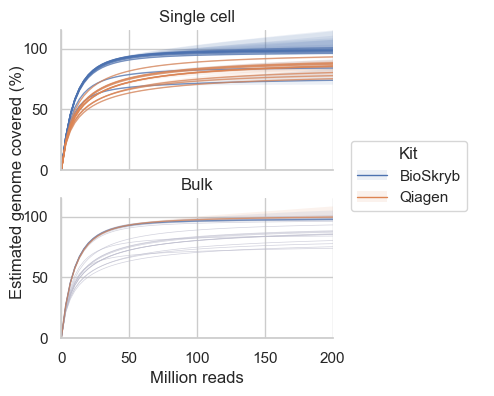

In [7]:
d = datagc.copy()

fig = plt.figure(figsize=(3.5,4))
fig.text(0, 0.5, "Estimated genome covered (%)", ha="center", va="center", 
         rotation=90, fontsize=12)
p = (
    so.Plot(d, x="Mreads", y="Genome coverage", color="Kit", group="NGI ID",
            ymin="Genome coverage Lower", ymax="Genome coverage Upper",)
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.7), color="Kit", group="NGI ID")
    .add(so.Band(alpha=0.1))
    .limit(y=(0,115), x=(0, 200))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Million reads",
        y="",
    )
    .on(fig)
    .save(figdir / "gc_extrap_genome_coverage_40M_narrow.svg", dpi=300, bbox_inches="tight", transparent=True)
)